# WRDS

**Research Question:** How does stress in the non-financial commercial paper market influence firms' working capital management and supply-chain operations?

**Scope:** Firm-level panel construction using Compustat (via WRDS) and Capital IQ. CP-issuing firms from the EDGAR sample are linked to Compustat gvkeys; a complementary CIQ arm recovers confirmed issuers missed by the EDGAR text search. Each treatment firm is matched to up to three control firms from the non-CP Compustat universe on size and leverage within SIC industry cells.

**Output:** A matched treatment-control panel with quarterly working capital variables, CIQ debt structure, and S&P credit ratings saved to `data/WR_wc_panel_enriched.csv`, ready for difference-in-differences estimation.

## Section 1 – Imports & Configuration

In [4]:
# Imports
import warnings
warnings.filterwarnings("ignore", category=Warning, module="urllib3")

# Core
import os
import re
import sys
from pathlib import Path

# Data
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.stats import gaussian_kde, mstats, t

# Econometrics
import statsmodels.formula.api as smf
from statsmodels.stats.sandwich_covariance import cov_cluster

# Visualisation
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# WRDS
import wrds

# Configuration
from dotenv import load_dotenv
sys.path.insert(0, str(Path().resolve().parent))
from config import *

load_dotenv(ANALYSIS_DIR / ".env")

db = wrds.Connection(
    wrds_username=os.getenv("WRDS_USERNAME"),
    wrds_password=os.getenv("WRDS_PASSWORD"),
)

Loading library list...
Done


## Section 2 – Sample Construction

CP-issuing firms are identified through two complementary arms and matched to Compustat identifiers. The EDGAR arm links CIK numbers from `ED_cp_final_sample.csv` to gvkeys via `comp.company`; a manual patch layer resolves firms missed by the automated link. The CIQ arm recovers confirmed issuers with observed CP outstanding in 2007 or 2019 that were not captured by the EDGAR text search. The two arms are unioned into a single treatment universe, enriched with clean company names and tickers, and exported as `WR_cp_master_sample.csv`.

- **2.1** CIK–gvkey link
- **2.2** Manual patches & exclusions
- **2.3** CIQ arm & treatment union
- **2.4** Names, tickers & master table

In [5]:
# CELL 2.1 — CIK–gvkey link

df = pd.read_csv(DATA_DIR / 'ED_cp_final_sample.csv')

link_df = db.raw_sql("""
    SELECT cik, gvkey
    FROM comp.company
    WHERE cik IS NOT NULL
""")

df['cik_norm'] = df['cik_norm'].astype(str)
link_df['cik'] = link_df['cik'].astype(str).str.lstrip('0')
df['cik_key']  = df['cik_norm'].astype(str).str.lstrip('0')

merged = df.merge(link_df, left_on='cik_key', right_on='cik', how='left')

print(f"Total rows: {len(merged)}")
print(f"Matched:    {merged['gvkey'].notna().sum()}")
print(f"Unmatched:  {merged['gvkey'].isna().sum()}")

unmatched = merged[merged['gvkey'].isna()][['cik_norm', 'cik_key', 'company_name', 'search_year']]
print(unmatched)

Total rows: 150
Matched:    137
Unmatched:  13
    cik_norm  cik_key                                     company_name  \
9    1170565  1170565  WEATHERFORD INTERNATIONAL LTD  (CIK 0001170565)   
19   1087835  1087835             BOTTLING GROUP LLC  (CIK 0001087835)   
35   1144519  1144519                      Bunge LTD  (CIK 0001144519)   
36   1160497  1160497          INGERSOLL RAND CO LTD  (CIK 0001160497)   
38      6769     6769                    APACHE CORP  (CIK 0000006769)   
52     64670    64670                  MEDTRONIC INC  (CIK 0000064670)   
64    104207   104207                    WALGREEN CO  (CIK 0000104207)   
65    826083   826083                       DELL INC  (CIK 0000826083)   
93   1144519  1144519                      Bunge LTD  (CIK 0001144519)   
103  1623613  1623613                     Mylan N.V.  (CIK 0001623613)   
113     6769     6769                    APACHE CORP  (CIK 0000006769)   
116  1619739  1619739     Hess Midstream Partners LP  (CIK 000161

### 2.2 — Manual patches & exclusions

Corporate actions — inversions, renames, going-private events, spinoffs, and bankruptcy restructurings — caused CIK continuity to break in `comp.company` for a subset of firms. Each patch is confirmed against Compustat coverage; known data gaps within the panel window are noted inline.

Two firms are excluded entirely:

- **Bottling Group LLC** (CIK 0001087835) — debt-only subsidiary; financials consolidated into parent Pepsi Bottling Group (gvkey 119417), inclusion would double-count working capital.
- **Mylan N.V.** (CIK 0001623613) — redomiciled to a Dutch holding structure after its 2015 inversion; neither the N.V. wrapper nor its predecessor gvkey return quarterly observations in `fundq`.

In [6]:
# CELL 2.2 — Manual patches & exclusions

manual_mapping = {
    '64670':   '007228',  # Medtronic Inc → Medtronic PLC (Ireland inversion 2015; gvkey continuous)
    '104207':  '011264',  # Walgreen Co → Walgreens Boots Alliance (renamed 2014)
    '1144519': '144435',  # Bunge Ltd → Bunge Global SA (Switzerland redomicile; cosmetic)
    '6769':    '001678',  # Apache Corp → APA Corp (Compustat bridges full history onto new holding CIK)
    '826083':  '014489',  # Dell Inc → Dell Technologies (private 2013–2018; expect NaNs in that window)
    '1160497': '030098',  # Ingersoll-Rand → Ingersoll Rand Inc (NaNs 2013–2014; Allegion spinoff; crisis years clean)
    '1170565': '004367',  # Weatherford Intl Ltd → PLC (bankruptcy 2019, fresh-start accounting; gvkey retained)
    '1619739': '021833',  # Hess Midstream Partners LP → LP→Corp conversion; 2019 coverage confirmed
    '45876':   '005496',  # Harsco Corp → Enviri Corp (renamed 2023; matched via ticker NVRI)
}

def patch_gvkey(row):
    if pd.isna(row['gvkey']):
        return manual_mapping.get(row['cik_key'], None)
    return row['gvkey']

merged['gvkey'] = merged.apply(patch_gvkey, axis=1)

merged = merged[~merged['cik_key'].isin(['1087835', '1623613'])]

print(f"Total rows     : {len(merged)}")
print(f"Matched        : {merged['gvkey'].notna().sum()}")
print(f"Still unmatched: {merged['gvkey'].isna().sum()}")

still_unmatched = merged[merged['gvkey'].isna()][['cik_norm', 'cik_key', 'company_name', 'search_year']]
if not still_unmatched.empty:
    print(still_unmatched.to_string())

Total rows     : 148
Matched        : 148
Still unmatched: 0


### 2.3 — CIQ arm & treatment union

The CIQ arm identifies CP issuers missed by the EDGAR text search: firms with observed CP outstanding > 0 in CIQ in 2007 or 2019 that pass the same SIC filters. EDGAR captures firms with active CP programs regardless of quarter-end balances; CIQ captures firms whose disclosures used non-standard phrasing but had confirmed outstanding balances. The two arms are complementary and unioned into a single treatment universe.

In [7]:
# CELL 2.3 — CIQ arm & treatment union

ciq_arm_raw = db.raw_sql("""
    WITH ranked AS (
        SELECT
            s.gvkey,
            n.conm                             AS company_name,
            n.sic,
            n.fic,
            EXTRACT(YEAR FROM s.periodenddate) AS search_year,
            s.totoutstbalcommercialpaper        AS cp_outstanding,
            ROW_NUMBER() OVER (
                PARTITION BY s.gvkey, EXTRACT(YEAR FROM s.periodenddate)
                ORDER BY s.filingdate DESC, s.financialinstanceid DESC
            ) AS rn
        FROM ciq_capstrct.wrds_summary s
        LEFT JOIN comp.company n
            ON LPAD(CAST(s.gvkey AS VARCHAR), 6, '0') =
               LPAD(CAST(n.gvkey AS VARCHAR), 6, '0')
        WHERE s.latestforfinancialperiodflag = 1
          AND s.latestfilingforinstanceflag  = 1
          AND s.periodtypename               = 'Quarterly'
          AND s.totoutstbalcommercialpaper    > 0
          AND EXTRACT(YEAR FROM s.periodenddate) IN (2007, 2019)
    )
    SELECT gvkey, company_name, sic, fic, search_year
    FROM ranked
    WHERE rn = 1
      AND sic IS NOT NULL
      AND fic = 'USA'
""")

ciq_arm_raw['sic'] = pd.to_numeric(ciq_arm_raw['sic'], errors='coerce')

ciq_arm = ciq_arm_raw[
    ciq_arm_raw['sic'].notna() &
    ~ciq_arm_raw['sic'].between(6000, 6999) &
    ~ciq_arm_raw['sic'].between(4900, 4999) &
    ~ciq_arm_raw['sic'].between(4610, 4619) &
    ~ciq_arm_raw['sic'].between(9000, 9999) &
    ~ciq_arm_raw['sic'].between(7350, 7359) &
    ~ciq_arm_raw['sic'].between(5170, 5172) &
    ~ciq_arm_raw['sic'].between(7510, 7519)
].copy()

ciq_arm['sic']         = ciq_arm['sic'].astype(int)
ciq_arm['search_year'] = ciq_arm['search_year'].astype(int)
ciq_arm['gvkey']       = ciq_arm['gvkey'].astype(str).str.zfill(6)

edgar_gvkeys = set(merged['gvkey'].dropna().astype(str).str.zfill(6).unique())
ciq_arm_new  = ciq_arm[~ciq_arm['gvkey'].isin(edgar_gvkeys)].copy()
ciq_arm_new  = ciq_arm_new.drop_duplicates(subset=['gvkey', 'search_year'])

both_years  = ciq_arm_new.groupby('gvkey')['search_year'].nunique()
ciq_arm_new['in_both_periods'] = ciq_arm_new['gvkey'].map(both_years > 1)
ciq_arm_new['status']          = 'ciq_identified'
ciq_arm_new['cik_norm']        = None
ciq_arm_new['accession_no']    = None

print(f"CIQ arm — new firms only (not in EDGAR):")
print(f"  2007       : {ciq_arm_new[ciq_arm_new['search_year']==2007]['gvkey'].nunique()}")
print(f"  2019       : {ciq_arm_new[ciq_arm_new['search_year']==2019]['gvkey'].nunique()}")
print(f"  Both years : {ciq_arm_new['in_both_periods'].sum() // 2}")
print(f"  Union      : {ciq_arm_new['gvkey'].nunique()}")

merged['gvkey']  = merged['gvkey'].astype(str).str.zfill(6)
merged['status'] = merged['status'].fillna('edgar_identified')

keep_cols = ['gvkey', 'cik_norm', 'sic', 'search_year',
             'in_both_periods', 'status', 'accession_no']

merged_combined = pd.concat([
    merged[keep_cols],
    ciq_arm_new[keep_cols],
], ignore_index=True).drop_duplicates(subset=['gvkey', 'search_year'])

all_treatment_gvkeys = set(merged_combined['gvkey'].unique())

print(f"\nCombined treatment universe:")
print(f"  EDGAR arm   : {len(edgar_gvkeys)}")
print(f"  CIQ new     : {ciq_arm_new['gvkey'].nunique()}")
print(f"  Total rows  : {len(merged_combined)}")
print(f"  Unique firms: {merged_combined['gvkey'].nunique()}")

merged = merged_combined

CIQ arm — new firms only (not in EDGAR):
  2007       : 80
  2019       : 83
  Both years : 44
  Union      : 119

Combined treatment universe:
  EDGAR arm   : 127
  CIQ new     : 119
  Total rows  : 311
  Unique firms: 246


In [8]:
# CELL 2.4 — Names, tickers & master table

gvkeys     = merged['gvkey'].dropna().unique().tolist()
gvkey_list = ', '.join(f"'{g}'" for g in gvkeys)

co = db.raw_sql(f"""
    SELECT gvkey, conm, conml, priusa, prirow, prican
    FROM comp.company WHERE gvkey IN ({gvkey_list})
""")
se = db.raw_sql(f"""
    SELECT gvkey, iid, tic, tpci, secstat, exchg, excntry
    FROM comp.security WHERE gvkey IN ({gvkey_list})
""")

def clean_primary(t):
    # Strip numeric reuse suffixes (.1, .2) while preserving real share classes (LEN.B)
    if not isinstance(t, str) or not t:
        return None
    return re.sub(r'\.\d*$', '', t)

def is_real_class(t):
    # Exclude numeric placeholders, reuse suffixes, when-issued, and bare dots
    if not isinstance(t, str) or not t:       return False
    if t[0].isdigit():                        return False
    if re.search(r'\.\d+$', t):               return False
    if t.endswith('.WI') or t.endswith('.'): return False
    return True

co['prim_iid_n'] = (co['priusa'].fillna(co['prirow']).fillna(co['prican'])
                    .astype(str).str.strip().str.lstrip('0'))
se['iid_n'] = se['iid'].astype(str).str.strip().str.lstrip('0')

prim = (se.merge(co[['gvkey','prim_iid_n']], on='gvkey')
          .query("iid_n == prim_iid_n")[['gvkey','tic']].drop_duplicates('gvkey'))
prim['ticker'] = prim['tic'].apply(clean_primary)

classes   = se[se['tpci'] == '0'].copy()
classes   = classes[classes['tic'].apply(is_real_class)]
tick_list = (classes.groupby('gvkey')['tic']
             .apply(lambda s: sorted(set(s))).rename('tickers_common'))

lookup = (co[['gvkey','conm','conml']]
          .merge(prim[['gvkey','ticker']], on='gvkey', how='left')
          .merge(tick_list,                on='gvkey', how='left'))
lookup['tickers_common'] = lookup['tickers_common'].apply(lambda x: x if isinstance(x, list) else [])
lookup['tickers_common'] = lookup.apply(
    lambda r: sorted(set(r['tickers_common']) | ({r['ticker']} if r['ticker'] else set())), axis=1)
lookup['ticker'] = lookup.apply(
    lambda r: r['ticker'] if isinstance(r['ticker'], str) and r['ticker']
              else (r['tickers_common'][0] if r['tickers_common'] else None), axis=1)
lookup['n_common'] = lookup['tickers_common'].apply(len)

if 'company_name' in merged.columns:
    merged = merged.rename(columns={'company_name': 'company_name_raw'})
merged = merged.drop(columns=['conm','company_clean','ticker','tickers_common','n_common'], errors='ignore')
merged = merged.merge(lookup[['gvkey','conm','ticker','tickers_common','n_common']], on='gvkey', how='left')
merged['company_clean'] = merged['conm']

print(f"gvkeys enriched             : {lookup['gvkey'].nunique()} / {len(gvkeys)}")
print(f"missing primary ticker      : {lookup['ticker'].isna().sum()}")
n_suffix = lookup['ticker'].str.contains(r'\.\d', na=False).sum()
print(f"primaries w/ numeric suffix : {n_suffix}  (should be 0)")
print("\nMulti-class common firms (eyeball primary):")
print(lookup[lookup['n_common'] > 1][['gvkey','conm','ticker','tickers_common']].to_string(index=False))

# Build and export master sample table
meta     = db.raw_sql(f"""
    SELECT gvkey, dldte
    FROM comp.company
    WHERE gvkey IN ({gvkey_list})
""")
funda    = db.raw_sql(f"""
    SELECT gvkey, fyear, datadate, at, act, lct
    FROM comp.funda
    WHERE gvkey IN ({', '.join(f"'{g}'" for g in gvkeys)})
      AND indfmt = 'INDL'
      AND datafmt = 'STD'
      AND popsrc = 'D'
      AND consol = 'C'
      AND fyear BETWEEN 2000 AND 2026
    ORDER BY gvkey, fyear
""")
coverage = (
    funda.groupby('gvkey')
    .agg(fyear_min=('fyear', 'min'), fyear_max=('fyear', 'max'))
    .reset_index()
)

def get_data_quality(grp):
    nan_act = grp['act'].isna()
    if nan_act.all():   return 'no_wc'
    if nan_act.any():   return 'partial_wc'
    return 'full'

quality = (
    funda.groupby('gvkey')
    .apply(get_data_quality)
    .reset_index()
    .rename(columns={0: 'data_quality'})
)

master = (
    merged[['gvkey', 'cik_norm', 'conm', 'ticker', 'tickers_common', 'search_year', 'sic']]
    .rename(columns={'conm': 'company_name'})
    .merge(meta,     on='gvkey', how='left')
    .merge(coverage, on='gvkey', how='left')
    .merge(quality,  on='gvkey', how='left')
    .sort_values(['search_year', 'company_name'])
    .reset_index(drop=True)
)

print(f"\nMaster sample: {len(master)} rows ({master['gvkey'].nunique()} unique companies)")
print(f"\nRows per crisis window:")
print(master['search_year'].value_counts().sort_index().to_string())
print(f"\nData quality breakdown:")
print(master['data_quality'].value_counts().to_string())

master.to_csv(DATA_DIR / 'WR_cp_master_sample.csv', index=False)
print(f"\nSaved: WR_cp_master_sample.csv")

gvkeys enriched             : 246 / 246
missing primary ticker      : 0
primaries w/ numeric suffix : 0  (should be 0)

Multi-class common firms (eyeball primary):
 gvkey                         conm ticker      tickers_common
002435            BROWN FORMAN CORP   BF.B        [BF.A, BF.B]
002490 BURLINGTON NORTHERN SANTA FE   BRK3         [BNI, BRK3]
002710         CONSTELLATION BRANDS    STZ        [STZ, STZ.B]
003226                 COMCAST CORP  CMCSA      [CMCSA, CMCSK]
003505     MOLSON COORS BEVERAGE CO    TAP [TAP, TAP.A, TAP.Z]
004367         WEATHERFORD INTL PLC   WFRD       [WFRD, WFTIQ]
005073            GENERAL MOTORS CO     GM  [GM, GMM.U, MTLQQ]
005568               KRAFT HEINZ CO    KHC          [HNZ, KHC]
005750 HOVNANIAN ENTRPRS INC  -CL A    HOV        [HOV, HOVVB]
005764                  HUBBELL INC   HUBB       [HUB.A, HUBB]
006307          SEARS HOLDINGS CORP  SHLDQ      [KMRTQ, SHLDQ]
006669                  LENNAR CORP    LEN        [LEN, LEN.B]
006730           

## Section 3 – Treatment Panel

Quarterly Compustat data (`fundq`) is pulled for all treatment firms over 2000–2025. Working capital variables, cash flow items, and leverage covariates are constructed from raw fields; YTD cash flow items are de-cumulated to quarterly. All ratio variables are winsorized at 1%/99% after removal of zero and negative denominators; raw dollar flows are left unwinsorized.

Two industries in the sample file unclassified balance sheets, so `actq`/`lctq` are null by construction — this is structural, not missing data:

- **Homebuilders** (SIC 152x/1531) — land and WIP homes sit in inventory with no current/non-current split.
- **Rental-fleet / leasing** (SIC 7510/7359) — the core asset is a financed fleet, not classified working capital.

The primary WC measure is therefore component-based operating NWC = `rect + invt − ap`, which is defined even where classified subtotals are not. DSO/DPO/DIO/CCC are component-based throughout and unaffected. Fleet firms are retained for the credit and supply-chain analysis only.

In [9]:
gvkeys = master['gvkey'].dropna().unique().tolist()

wc_q = db.raw_sql(f"""
    SELECT
        gvkey,
        datadate,
        fyearq,
        fqtr,
        rectq   AS ar,
        invtq   AS inventory,
        apq     AS ap,
        cheq    AS cash,
        actq    AS current_assets,
        lctq    AS current_liabilities,
        saleq   AS revenue,
        cogsq   AS cogs,
        atq     AS total_assets,
        dlcq    AS short_term_debt,
        dlttq   AS long_term_debt,
        cshoq   AS shares_out,
        prccq   AS price,
        npq     AS notes_payable,
        dd1q    AS ltd_due_one_year,
        capxy   AS capex,
        niq     AS net_income,
        oibdpq  AS ebitda,
        oancfy  AS cfo,
        xintq   AS interest_paid
    FROM comp.fundq
    WHERE gvkey IN ({', '.join(f"'{g}'" for g in gvkeys)})
      AND indfmt  = 'INDL'
      AND datafmt = 'STD'
      AND popsrc  = 'D'
      AND consol  = 'C'
      AND datadate BETWEEN '2000-01-01' AND '2025-12-31'
    ORDER BY gvkey, datadate
""")

wc_q['datadate'] = pd.to_datetime(wc_q['datadate']).dt.normalize()
wc_q['fqtr']     = wc_q['fqtr'].astype('Int64')
wc_q             = wc_q.sort_values(['gvkey', 'fyearq', 'fqtr']).reset_index(drop=True)

# oancfy and capxy are fiscal-YTD cumulative in fundq; diff within fiscal year.
# Q1 has no prior quarter — raw YTD IS the quarterly value.
# Float cast on fqtr avoids nullable Int64 comparison returning pd.NA instead of True.
for col in ['cfo', 'capex']:
    wc_q[f'{col}_ytd'] = wc_q[col]
    wc_q[col] = (
        wc_q.groupby(['gvkey', 'fyearq'])[col]
        .transform(lambda s: s.diff())
    )
    q1_mask = (wc_q['fqtr'].astype('float') == 1.0) & wc_q[f'{col}_ytd'].notna()
    wc_q.loc[q1_mask, col] = wc_q.loc[q1_mask, f'{col}_ytd']

wc_q['log_assets'] = np.log(wc_q['total_assets'].replace(0, np.nan))
wc_q['leverage']   = (
    (wc_q['short_term_debt'].fillna(0) + wc_q['long_term_debt'].fillna(0))
    / wc_q['total_assets'].replace(0, np.nan)
)
wc_q['market_cap'] = wc_q['shares_out'] * wc_q['price']

wc_q['nwc'] = wc_q['current_assets'] - wc_q['current_liabilities']

# Require at least one asset-side component; avoid manufacturing a value from payables alone
wc_q['nwc_operating'] = (
    wc_q['ar'].fillna(0) + wc_q['inventory'].fillna(0) - wc_q['ap'].fillna(0)
)
wc_q.loc[wc_q['ar'].isna() & wc_q['inventory'].isna(), 'nwc_operating'] = np.nan

wc_q['dso'] = np.where(wc_q['revenue'] > 0, (wc_q['ar']        / wc_q['revenue']) * 91.25, np.nan)
wc_q['dpo'] = np.where(wc_q['cogs']    > 0, (wc_q['ap']        / wc_q['cogs'])    * 91.25, np.nan)
wc_q['dio'] = np.where(wc_q['cogs']    > 0, (wc_q['inventory'] / wc_q['cogs'])    * 91.25, np.nan)
wc_q['ccc'] = wc_q['dso'] + wc_q['dio'] - wc_q['dpo']

wc_q['nwc_ratio']    = np.where(wc_q['total_assets'] > 0, wc_q['nwc']           / wc_q['total_assets'], np.nan)
wc_q['nwc_op_ratio'] = np.where(wc_q['total_assets'] > 0, wc_q['nwc_operating'] / wc_q['total_assets'], np.nan)

wc_q['fcf'] = wc_q['cfo'] - wc_q['capex'].abs()

classified_firms      = wc_q.groupby('gvkey')['current_assets'].apply(lambda s: s.notna().any())
wc_q['bs_classified'] = wc_q['gvkey'].map(classified_firms)

# Winsorize ratios at 1%/99%; raw dollar flows left unwinsorized
for col in ['dso', 'dpo', 'dio', 'ccc', 'nwc_ratio', 'nwc_op_ratio', 'leverage']:
    clean = wc_q[col].replace([np.inf, -np.inf], np.nan)
    mask  = clean.notna()
    if mask.sum() > 1:
        clean[mask] = mstats.winsorize(clean[mask].to_numpy(dtype=float), limits=[0.01, 0.01])
    wc_q[col] = clean

wc_q['gvkey']        = wc_q['gvkey'].astype(int)
meta_map             = (master.drop_duplicates('gvkey')
                        .assign(gk=lambda d: d['gvkey'].astype(int))
                        .set_index('gk')[['company_name', 'ticker']])
wc_q['company_name'] = wc_q['gvkey'].map(meta_map['company_name'])
wc_q['ticker']       = wc_q['gvkey'].map(meta_map['ticker'])

pulled   = set(wc_q['gvkey'].unique())
expected = set(master['gvkey'].dropna().astype(int).unique())
missing  = expected - pulled
if missing:
    print(f"Missing gvkeys: {missing}")
else:
    print("All companies accounted for.")

print(f"Rows      : {len(wc_q):,}")
print(f"Companies : {wc_q['gvkey'].nunique()}")
print(f"Date range: {wc_q['datadate'].min().date()} → {wc_q['datadate'].max().date()}")

print(f"\nInf check (should all be 0):")
for col in ['dso', 'dpo', 'dio', 'ccc']:
    print(f"  {col}: {np.isinf(wc_q[col]).sum()} inf values")

print(f"\nNaN rates:")
for col in ['nwc_ratio', 'nwc_op_ratio', 'dso', 'dpo', 'dio', 'ccc',
            'leverage', 'log_assets', 'cfo', 'fcf']:
    print(f"  {col}: {wc_q[col].isna().mean() * 100:.1f}%")

unclassified = wc_q[~wc_q['bs_classified']]
print(f"\nUnclassified-BS firms: {unclassified['gvkey'].nunique()}")
print(f"  nwc (classified) coverage : {unclassified['nwc'].notna().mean()*100:.1f}%  (expected ~0)")
print(f"  nwc_operating coverage    : {unclassified['nwc_operating'].notna().mean()*100:.1f}%")

wc_q = wc_q.drop(columns=['cfo_ytd', 'capex_ytd'])
wc_q.to_csv(DATA_DIR / 'WR_wc_quarterly_panel.csv', index=False)
print(f"\nSaved: WR_wc_quarterly_panel.csv")

Missing gvkeys: {22242}
Rows      : 22,835
Companies : 245
Date range: 2000-01-31 → 2025-12-31

Inf check (should all be 0):
  dso: 0 inf values
  dpo: 0 inf values
  dio: 0 inf values
  ccc: 0 inf values

NaN rates:
  nwc_ratio: 5.9%
  nwc_op_ratio: 1.0%
  dso: 2.2%
  dpo: 1.4%
  dio: 3.1%
  ccc: 4.4%
  leverage: 0.9%
  log_assets: 0.9%
  cfo: 1.6%
  fcf: 1.8%

Unclassified-BS firms: 9
  nwc (classified) coverage : 0.0%  (expected ~0)
  nwc_operating coverage    : 100.0%

Saved: WR_wc_quarterly_panel.csv


## Section 4 – Control Group

Control firms are drawn from the Compustat INDL universe and matched to treatment firms separately for each crisis year using Q4 covariates from the pre-crisis year (t−1). The matched control panel is constructed identically to the treatment panel in Section 3 and combined into a single DiD-ready dataset.

- **4.1** Control candidate universe
- **4.2** Nearest-neighbor matching
- **4.3** Control panel & combined dataset
- **4.4** Parallel pre-trends
- **4.5** Industry composition

### 4.1 — Control candidate universe

Candidates are drawn from non-CP Compustat INDL firms with Q4 data in the pre-crisis year, applying the same SIC exclusions as the EDGAR arm. The size bounds restrict the pool to [min − 0.5, max + 0.5] log_assets relative to the treatment group's per-crisis-year range, where 0.5 equals the LA caliper. Firms with leverage outside [0, 1] are dropped.

In [10]:
# 4.1 Control candidate universe

# Hyperparameters
W_LA          = 0.6
W_LEV         = 0.4
CALIPER_LA    = 0.5
CALIPER_LEV   = 0.25
MIN_CELL_SIZE = 5
RATIO         = 3
SNAP_FQTR     = 4

master = pd.read_csv(DATA_DIR / 'WR_cp_master_sample.csv')
wc_q   = pd.read_csv(DATA_DIR / 'WR_wc_quarterly_panel.csv', parse_dates=['datadate'])

treatment_map = (
    master[master['gvkey'].notna()]
    .groupby('search_year')['gvkey']
    .apply(lambda x: set(x.astype(float).astype(int)))
    .to_dict()
)
all_treatment_gvkeys = set(master['gvkey'].dropna().astype(float).astype(int))

sic_map = (
    master[master['sic'].notna()][['gvkey', 'sic']]
    .drop_duplicates('gvkey')
    .assign(sic2=lambda d: (d['sic'] // 100).astype(int),
            sic1=lambda d: (d['sic'] // 1000).astype(int))
    .set_index('gvkey')
)

snap_years          = sorted({yr - 1 for yr in treatment_map.keys()})
treatment_gvkey_sql = ', '.join(f"'{int(g):06d}'" for g in all_treatment_gvkeys)
snap_year_sql       = ', '.join(str(y) for y in snap_years)

candidate_raw = db.raw_sql(f"""
    SELECT
        f.gvkey,
        c.sic,
        f.fyearq,
        f.fqtr,
        f.datadate,
        f.atq     AS total_assets,
        f.dlcq    AS short_term_debt,
        f.dlttq   AS long_term_debt
    FROM comp.fundq f
    JOIN comp.company c USING (gvkey)
    WHERE f.indfmt  = 'INDL'
      AND f.datafmt = 'STD'
      AND f.popsrc  = 'D'
      AND f.consol  = 'C'
      AND f.fyearq  IN ({snap_year_sql})
      AND f.fyearq  BETWEEN 2000 AND 2025
      AND f.fqtr    = {SNAP_FQTR}
      AND f.atq     > 0
      AND f.gvkey   NOT IN ({treatment_gvkey_sql})
      AND f.datadate BETWEEN '2000-01-01' AND '2025-12-31'
      AND c.fic = 'USA'
      AND CAST(c.sic AS INTEGER) NOT BETWEEN 6000 AND 6999
      AND CAST(c.sic AS INTEGER) NOT BETWEEN 4900 AND 4999
      AND CAST(c.sic AS INTEGER) NOT BETWEEN 4610 AND 4619
      AND CAST(c.sic AS INTEGER) NOT BETWEEN 9000 AND 9999
      AND CAST(c.sic AS INTEGER) NOT BETWEEN 7350 AND 7359
      AND CAST(c.sic AS INTEGER) NOT BETWEEN 5170 AND 5172
      AND CAST(c.sic AS INTEGER) NOT BETWEEN 7510 AND 7519
    ORDER BY f.gvkey, f.fyearq
""")

candidate_raw['log_assets'] = np.log(candidate_raw['total_assets'].replace(0, np.nan))
candidate_raw['leverage']   = (
    (candidate_raw['short_term_debt'].fillna(0) + candidate_raw['long_term_debt'].fillna(0))
    / candidate_raw['total_assets'].replace(0, np.nan)
)
candidate_raw['sic2'] = (candidate_raw['sic'].astype(float) // 100).astype('Int64')
candidate_raw['sic1'] = (candidate_raw['sic'].astype(float) // 1000).astype('Int64')
candidate_raw = candidate_raw.dropna(subset=['log_assets', 'leverage'])
candidate_raw = candidate_raw.drop_duplicates(subset=['gvkey', 'fyearq'])

print(f"Candidate universe: {len(candidate_raw):,} firm-year snapshots "
      f"({candidate_raw['gvkey'].nunique():,} unique gvkeys)")

Candidate universe: 8,124 firm-year snapshots (6,412 unique gvkeys)


### 4.2 — Nearest-neighbor matching

Matching is performed within SIC2 industry cells (SIC1 fallback if cell < 5 firms) on weighted Euclidean distance over log_assets (weight 0.6) and leverage (weight 0.4), normalised by pooled standard deviations. Calipers of ±0.5 log-points and ±0.25 on leverage are applied independently; up to 3 matches per treatment firm. Matching is with replacement; standard errors are clustered at the firm level throughout.

In [11]:
# 4.2 Nearest-neighbor matching

def get_treatment_snapshot(wc_q, year):
    snap = (
        wc_q[(wc_q['fyearq'] == year - 1) & (wc_q['fqtr'] == SNAP_FQTR)]
        .copy()
        .dropna(subset=['log_assets', 'leverage'])
    )
    return snap[['gvkey', 'company_name', 'log_assets', 'leverage']].drop_duplicates('gvkey')


def match_one_crisis(year, treatment_gvkeys, wc_q, candidate_raw, sic_map,
                     w_la=W_LA, w_lev=W_LEV,
                     cal_la=CALIPER_LA, cal_lev=CALIPER_LEV,
                     min_cell=MIN_CELL_SIZE, ratio=RATIO):
    treat_snap = get_treatment_snapshot(wc_q, year)
    treat_snap = treat_snap[treat_snap['gvkey'].isin(treatment_gvkeys)].copy()
    treat_snap['gvkey'] = treat_snap['gvkey'].astype(float).astype(int)
    treat_snap = treat_snap.join(sic_map[['sic2', 'sic1']], on='gvkey', how='left')
    nan_sic = treat_snap[treat_snap['sic2'].isna()]
    if not nan_sic.empty:
        print(f"  ⚠ {len(nan_sic)} firm(s) missing SIC after join: {nan_sic['gvkey'].tolist()}")
    treat_snap = treat_snap[treat_snap['leverage'].between(0, 1)].copy()

    cand_snap = candidate_raw[candidate_raw['fyearq'] == year - 1].copy()

    la_min = treat_snap['log_assets'].min() - cal_la
    la_max = treat_snap['log_assets'].max() + cal_la
    cand_snap = cand_snap[cand_snap['log_assets'].between(la_min, la_max)].copy()
    cand_snap = cand_snap[cand_snap['leverage'].between(0, 1)].copy()

    print(f"  Post-filter candidate pool: {len(cand_snap):,} firms")

    std_la  = pd.concat([treat_snap['log_assets'], cand_snap['log_assets']]).std() or 1.0
    std_lev = pd.concat([treat_snap['leverage'],   cand_snap['leverage']]).std()   or 1.0

    records = []
    for _, t in treat_snap.iterrows():
        cell2 = cand_snap[cand_snap['sic2'] == t['sic2']]
        if len(cell2) >= min_cell:
            use_cell, match_level = cell2.copy(), 'sic2'
        else:
            use_cell = cand_snap[cand_snap['sic1'] == t['sic1']].copy()
            match_level = 'sic1'
            if use_cell.empty:
                use_cell, match_level = cand_snap.copy(), 'unrestricted'

        use_cell = use_cell[(use_cell['log_assets'] - t['log_assets']).abs() <= cal_la]
        use_cell = use_cell[(use_cell['leverage']   - t['leverage']).abs()   <= cal_lev]

        if use_cell.empty:
            continue

        T_vec = np.array([[t['log_assets'] / std_la  * np.sqrt(w_la),
                           t['leverage']   / std_lev * np.sqrt(w_lev)]])
        C_mat = np.column_stack([
            use_cell['log_assets'].values / std_la  * np.sqrt(w_la),
            use_cell['leverage'].values   / std_lev * np.sqrt(w_lev),
        ])
        dists  = cdist(T_vec, C_mat, metric='euclidean').flatten()
        n_keep = min(ratio, len(dists))

        for idx in np.argsort(dists)[:n_keep]:
            c = use_cell.iloc[idx]
            records.append({
                'crisis_year':       year,
                'treatment_gvkey':   t['gvkey'],
                'treatment_company': t['company_name'],
                'control_gvkey':     c['gvkey'],
                'control_sic':       c['sic'],
                'match_level':       match_level,
                'distance':          dists[idx],
                't_log_assets':      t['log_assets'],
                't_leverage':        t['leverage'],
                'c_log_assets':      c['log_assets'],
                'c_leverage':        c['leverage'],
            })

    return pd.DataFrame(records)


match_frames = []
for year, t_gvkeys in sorted(treatment_map.items()):
    print(f"\n{'='*60}")
    print(f"Crisis year {year}  |  treatment firms: {len(t_gvkeys)}")
    mf = match_one_crisis(year, t_gvkeys, wc_q, candidate_raw, sic_map)
    match_frames.append(mf)

    n_matched = mf['treatment_gvkey'].nunique()
    n_treat   = len(t_gvkeys)
    print(f"  Treated firms w/ ≥1 match : {n_matched} / {n_treat} ({100*n_matched/n_treat:.0f}%)")
    print(f"  Unique controls           : {mf['control_gvkey'].nunique()}")
    print(f"  Total match pairs         : {len(mf)}")
    print(f"  Match level breakdown     :\n{mf['match_level'].value_counts().to_string()}")
    print(f"  Distance — mean={mf['distance'].mean():.4f}  "
          f"p50={mf['distance'].median():.4f}  "
          f"p95={mf['distance'].quantile(0.95):.4f}")

matches = pd.concat(match_frames, ignore_index=True)

usage = matches.groupby('control_gvkey').size().rename('usage_count')
matches = matches.join(usage, on='control_gvkey')
matches['control_weight'] = 1 / matches['usage_count']

print("\nControl firm usage distribution:")
print(usage.value_counts().sort_index().to_string())
print(f"\nFirms used once    : {(usage == 1).sum()}")
print(f"Firms used 2+ times: {(usage > 1).sum()}")

matched_treat   = set(matches['treatment_gvkey'].astype(str))
all_treat       = set(master['gvkey'].dropna().astype(str))
unmatched_treat = all_treat - matched_treat

print(f"\nUnmatched treatment firms (excluded from DiD): {len(unmatched_treat)}")
if unmatched_treat:
    unmatched_info = (
        master[master['gvkey'].astype(str).isin(unmatched_treat)]
        [['gvkey', 'company_name', 'search_year']]
        .drop_duplicates()
        .sort_values('search_year')
    )
    print(unmatched_info.to_string(index=False))
print(f"Included in DiD: {len(all_treat) - len(unmatched_treat)} / {len(all_treat)} treatment firms")

print(f"\nCovariate balance (treatment vs matched controls):")
for yr in sorted(matches['crisis_year'].unique()):
    m = matches[matches['crisis_year'] == yr]
    print(f"\n  Year {yr}:")
    for dim, tc, cc in [('log_assets', 't_log_assets', 'c_log_assets'),
                        ('leverage',   't_leverage',   'c_leverage')]:
        t_mean = m[tc].mean()
        c_mean = m[cc].mean()
        smd    = (t_mean - c_mean) / (m[tc].std() or 1)
        flag   = '✓' if abs(smd) < 0.1 else '△ review balance'
        print(f"    {dim:12s}  treat={t_mean:.3f}  ctrl={c_mean:.3f}  SMD={smd:.3f}  {flag}")

matches.to_csv(DATA_DIR / 'WR_control_matches.csv', index=False)
print(f"\nSaved {len(matches):,} match pairs → WR_control_matches.csv")


Crisis year 2007  |  treatment firms: 154
  Post-filter candidate pool: 2,377 firms
  Treated firms w/ ≥1 match : 121 / 154 (79%)
  Unique controls           : 206
  Total match pairs         : 282
  Match level breakdown     :
match_level
sic2    263
sic1     19
  Distance — mean=0.2581  p50=0.2218  p95=0.5922

Crisis year 2019  |  treatment firms: 157
  Post-filter candidate pool: 1,680 firms
  Treated firms w/ ≥1 match : 104 / 157 (66%)
  Unique controls           : 150
  Total match pairs         : 237
  Match level breakdown     :
match_level
sic2    218
sic1     19
  Distance — mean=0.2827  p50=0.2389  p95=0.6187

Control firm usage distribution:
usage_count
1    194
2     54
3     32
4     16
5      4
6      2
7      1
9      2

Firms used once    : 194
Firms used 2+ times: 111

Unmatched treatment firms (excluded from DiD): 55
 gvkey                 company_name  search_year
  1356                    ALCOA INC         2007
 11259                  WALMART INC         2007
  213

In [12]:
# CELL 4.3 — Control panel & combined dataset

control_gvkeys    = set(matches['control_gvkey'].unique())
control_gvkey_sql = ', '.join(f"'{g}'" for g in control_gvkeys)

wc_controls = db.raw_sql(f"""
    SELECT
        gvkey, datadate, fyearq, fqtr,
        rectq  AS ar,        invtq  AS inventory,  apq    AS ap,
        cheq   AS cash,      actq   AS current_assets,
        lctq   AS current_liabilities,
        saleq  AS revenue,   cogsq  AS cogs,        atq    AS total_assets,
        dlcq   AS short_term_debt,   dlttq  AS long_term_debt,
        cshoq  AS shares_out,        prccq  AS price,
        npq    AS notes_payable,     dd1q   AS ltd_due_one_year,
        capxy  AS capex,
        niq    AS net_income,        oibdpq AS ebitda,
        oancfy AS cfo,               xintq  AS interest_paid
    FROM comp.fundq
    WHERE gvkey IN ({control_gvkey_sql})
      AND indfmt  = 'INDL'
      AND datafmt = 'STD'
      AND popsrc  = 'D'
      AND consol  = 'C'
      AND fyearq  BETWEEN 2000 AND 2025
      AND datadate BETWEEN '2000-01-01' AND '2025-12-31'
    ORDER BY gvkey, datadate
""")

wc_controls['datadate'] = pd.to_datetime(wc_controls['datadate']).dt.normalize()
wc_controls['fqtr']     = wc_controls['fqtr'].astype('Int64')

# Impute fqtr from fiscal quarter-end month where missing
month_to_fqtr = {3: 1, 6: 2, 9: 3, 12: 4}
fqtr_missing  = wc_controls['fqtr'].isna()
if fqtr_missing.any():
    print(f"Imputing fqtr for {fqtr_missing.sum():,} rows with missing fqtr")
    wc_controls.loc[fqtr_missing, 'fqtr'] = (
        wc_controls.loc[fqtr_missing, 'datadate'].dt.month.map(month_to_fqtr)
    )
    still_missing = wc_controls['fqtr'].isna().sum()
    if still_missing:
        print(f"Dropping {still_missing:,} rows with non-standard fiscal quarter ends")
        wc_controls = wc_controls.dropna(subset=['fqtr'])
wc_controls['fqtr'] = wc_controls['fqtr'].astype('Int64')

wc_controls = wc_controls.sort_values(['gvkey', 'fyearq', 'fqtr']).reset_index(drop=True)

# Same de-cumulation logic as Section 3
for col in ['cfo', 'capex']:
    wc_controls[f'{col}_ytd'] = wc_controls[col]
    wc_controls[col] = (
        wc_controls.groupby(['gvkey', 'fyearq'])[col]
        .transform(lambda s: s.diff())
    )
    q1_mask = (wc_controls['fqtr'].astype('float') == 1.0) & wc_controls[f'{col}_ytd'].notna()
    wc_controls.loc[q1_mask, col] = wc_controls.loc[q1_mask, f'{col}_ytd']

wc_controls['log_assets'] = np.log(wc_controls['total_assets'].replace(0, np.nan))
wc_controls['leverage']   = (
    (wc_controls['short_term_debt'].fillna(0) + wc_controls['long_term_debt'].fillna(0))
    / wc_controls['total_assets'].replace(0, np.nan)
)
wc_controls['market_cap'] = wc_controls['shares_out'] * wc_controls['price']

wc_controls['nwc'] = wc_controls['current_assets'] - wc_controls['current_liabilities']

wc_controls['nwc_operating'] = (
    wc_controls['ar'].fillna(0) + wc_controls['inventory'].fillna(0) - wc_controls['ap'].fillna(0)
)
wc_controls.loc[wc_controls['ar'].isna() & wc_controls['inventory'].isna(), 'nwc_operating'] = np.nan

wc_controls['dso'] = np.where(wc_controls['revenue'] > 0,
    (wc_controls['ar']        / wc_controls['revenue']) * 91.25, np.nan)
wc_controls['dpo'] = np.where(wc_controls['cogs']    > 0,
    (wc_controls['ap']        / wc_controls['cogs'])    * 91.25, np.nan)
wc_controls['dio'] = np.where(wc_controls['cogs']    > 0,
    (wc_controls['inventory'] / wc_controls['cogs'])    * 91.25, np.nan)
wc_controls['ccc']          = wc_controls['dso'] + wc_controls['dio'] - wc_controls['dpo']
wc_controls['nwc_ratio']    = np.where(wc_controls['total_assets'] > 0,
    wc_controls['nwc']           / wc_controls['total_assets'], np.nan)
wc_controls['nwc_op_ratio'] = np.where(wc_controls['total_assets'] > 0,
    wc_controls['nwc_operating'] / wc_controls['total_assets'], np.nan)

wc_controls['fcf'] = wc_controls['cfo'] - wc_controls['capex'].abs()

classified_firms          = wc_controls.groupby('gvkey')['current_assets'].apply(lambda s: s.notna().any())
wc_controls['bs_classified'] = wc_controls['gvkey'].map(classified_firms)

for col in ['dso', 'dpo', 'dio', 'ccc', 'nwc_ratio', 'nwc_op_ratio', 'leverage']:
    clean = wc_controls[col].replace([np.inf, -np.inf], np.nan)
    mask  = clean.notna()
    if mask.sum() > 1:
        clean[mask] = mstats.winsorize(clean[mask].to_numpy(dtype=float), limits=[0.01, 0.01])
    wc_controls[col] = clean

ctrl_gvkey_list = ', '.join(f"'{g}'" for g in wc_controls['gvkey'].unique().tolist())
ctrl_meta = db.raw_sql(f"""
    SELECT
        c.gvkey,
        c.conm AS company_name,
        COALESCE(
            MAX(CASE WHEN s.iid = c.priusa THEN s.tic END),
            MAX(CASE WHEN s.iid = c.prirow THEN s.tic END),
            MAX(s.tic)
        ) AS ticker
    FROM comp.company c
    LEFT JOIN comp.security s USING (gvkey)
    WHERE c.gvkey IN ({ctrl_gvkey_list})
    GROUP BY c.gvkey, c.conm
""")

ctrl_meta_map               = ctrl_meta.set_index('gvkey')
wc_controls['company_name'] = wc_controls['gvkey'].map(ctrl_meta_map['company_name'])
wc_controls['ticker']       = wc_controls['gvkey'].map(ctrl_meta_map['ticker'])
wc_controls['group']        = 'control'

wc_controls = wc_controls.drop(columns=['cfo_ytd', 'capex_ytd'])
wc_controls.to_csv(DATA_DIR / 'WR_wc_controls_panel.csv', index=False)
print(f"Control panel → WR_wc_controls_panel.csv"
      f"({len(wc_controls):,} rows, {wc_controls['gvkey'].nunique()} firms)")

wc_q['group'] = 'treatment'
shared_cols   = [c for c in wc_q.columns if c in wc_controls.columns]
wc_panel      = pd.concat([wc_q[shared_cols], wc_controls[shared_cols]], ignore_index=True)
wc_panel      = wc_panel[wc_panel['datadate'].between('2000-01-01', '2025-12-31')].copy()

wc_panel.to_csv(DATA_DIR / 'WR_wc_panel_with_controls.csv', index=False)
print(f"Combined panel → WR_wc_panel_with_controls.csv")
print(f"  Treatment rows : {len(wc_q):,}  ({wc_q['gvkey'].nunique()} firms)")
print(f"  Control rows   : {len(wc_controls):,}  ({wc_controls['gvkey'].nunique()} firms)")

Imputing fqtr for 2 rows with missing fqtr
Control panel → WR_wc_controls_panel.csv(24,139 rows, 305 firms)
Combined panel → WR_wc_panel_with_controls.csv
  Treatment rows : 22,835  (245 firms)
  Control rows   : 24,139  (305 firms)


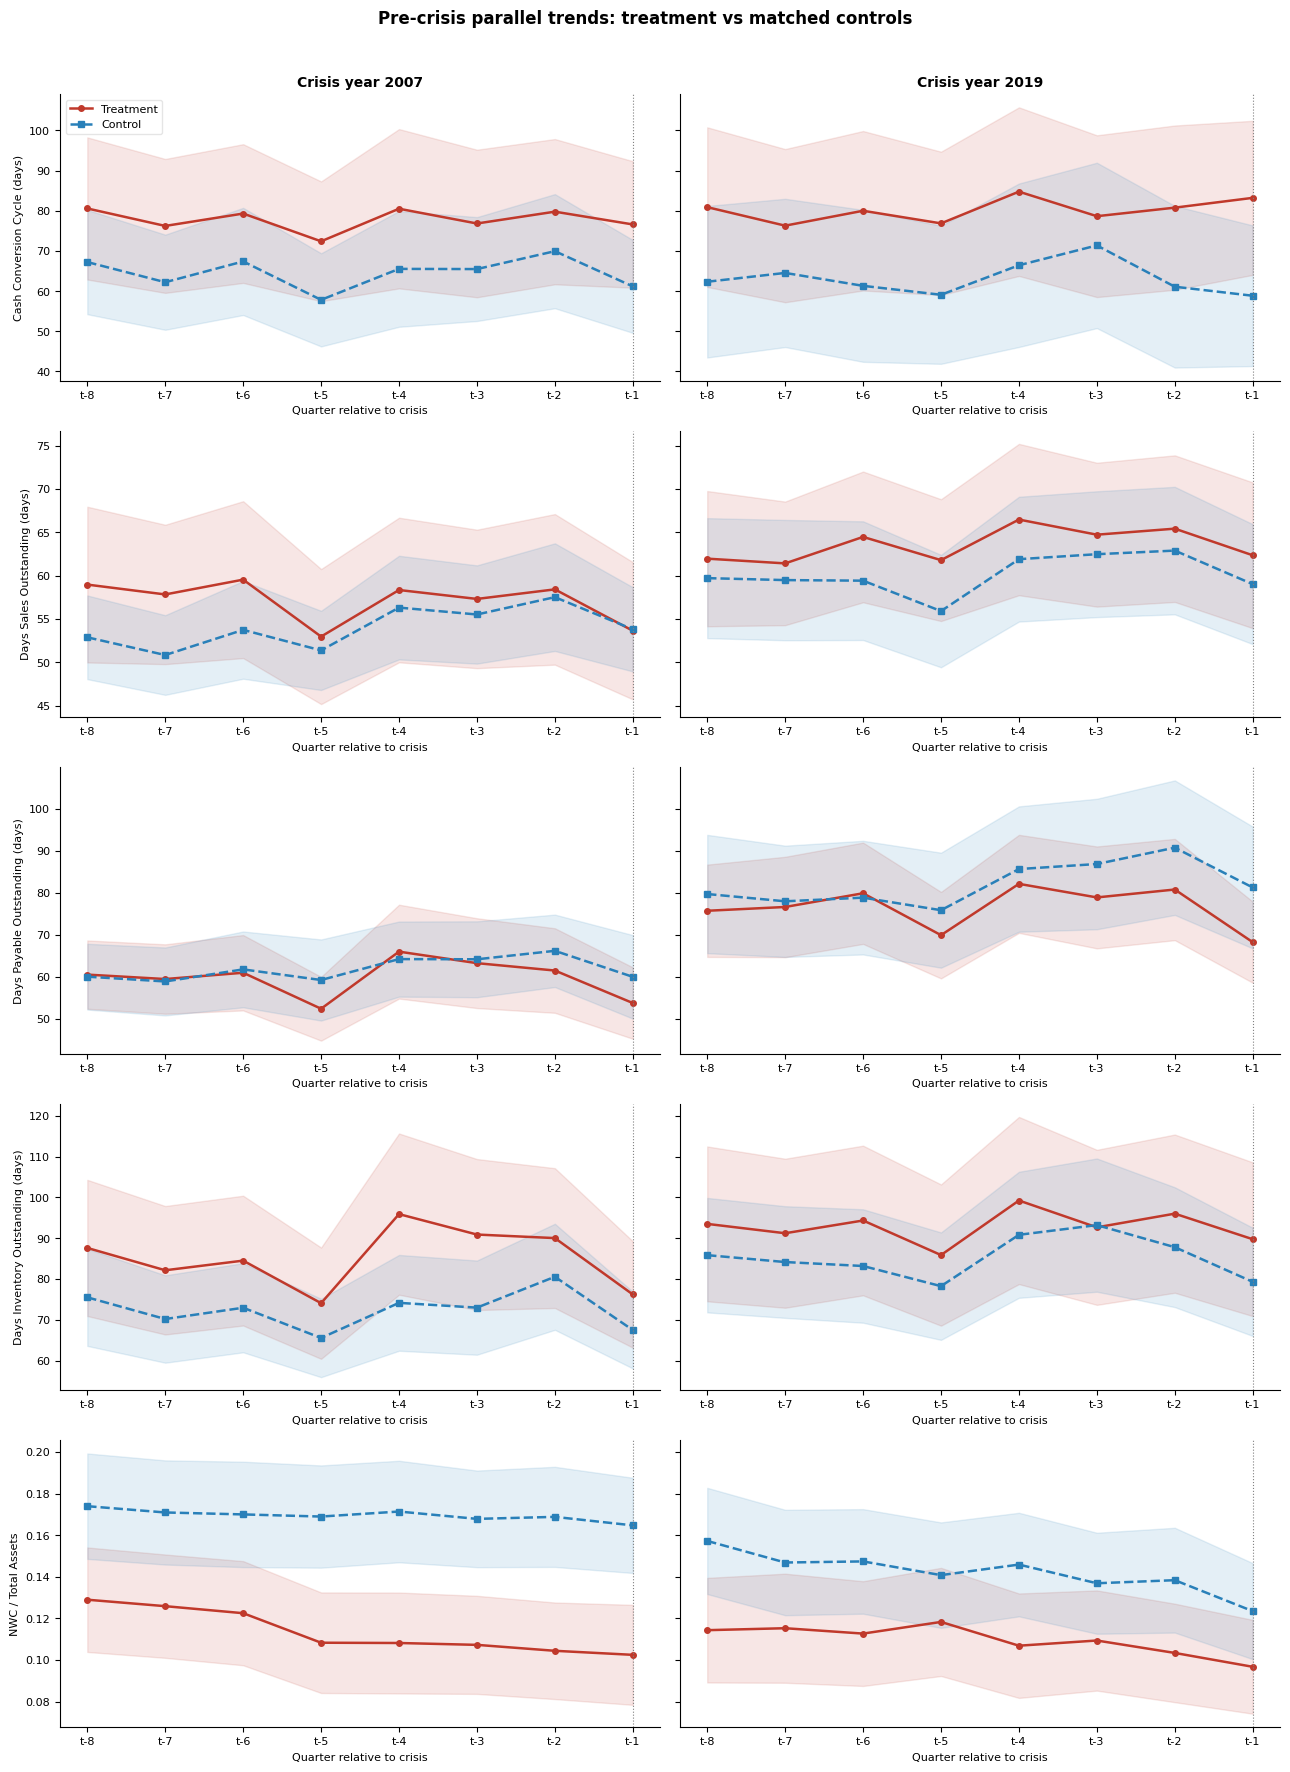

Saved → WR_parallel_trends.png

Formal pre-trend test (H0: no differential pre-trend)
Outcome      Crisis   β treat×rel_q    p-value       Result
------------------------------------------------------------
ccc            2007         -0.0858      0.908   ✓ parallel
dso            2007         -1.0210      0.038     △ review
dpo            2007         -0.7783      0.205   ✓ parallel
dio            2007         -0.0547      0.926   ✓ parallel
nwc_ratio      2007         -0.0031      0.052     △ review
ccc            2019          0.5721      0.681   ✓ parallel
dso            2019          0.0082      0.988   ✓ parallel
dpo            2019         -1.5618      0.155   ✓ parallel
dio            2019         -0.1009      0.924   ✓ parallel
nwc_ratio      2019          0.0012      0.445   ✓ parallel


In [13]:
# CELL 4.4 — Parallel pre-trends

CRISIS_YEARS   = [2007, 2019]
PRE_WINDOW     = 8
OUTCOMES       = ['ccc', 'dso', 'dpo', 'dio', 'nwc_ratio']
OUTCOME_LABELS = {
    'ccc':       'Cash Conversion Cycle (days)',
    'dso':       'Days Sales Outstanding (days)',
    'dpo':       'Days Payable Outstanding (days)',
    'dio':       'Days Inventory Outstanding (days)',
    'nwc_ratio': 'NWC / Total Assets',
}

wc_treat   = pd.read_csv(DATA_DIR / 'WR_wc_quarterly_panel.csv',  parse_dates=['datadate'])
wc_control = pd.read_csv(DATA_DIR / 'WR_wc_controls_panel.csv',   parse_dates=['datadate'])
matches    = pd.read_csv(DATA_DIR / 'WR_control_matches.csv')

wc_treat['group']   = 'treatment'
wc_control['group'] = 'control'

def add_rel_quarter(df, crisis_year):
    df = df.copy()
    df['rel_q'] = (df['fyearq'] - crisis_year) * 4 + (df['fqtr'] - 1)
    return df

fig, axes = plt.subplots(
    nrows=len(OUTCOMES), ncols=len(CRISIS_YEARS),
    figsize=(13, 3.5 * len(OUTCOMES)),
    sharey='row'
)

for col_idx, year in enumerate(CRISIS_YEARS):
    t_gvkeys = set(matches[matches['crisis_year'] == year]['treatment_gvkey'])
    c_gvkeys = set(matches[matches['crisis_year'] == year]['control_gvkey'])

    t_panel = add_rel_quarter(wc_treat[wc_treat['gvkey'].isin(t_gvkeys)],   year)
    c_panel = add_rel_quarter(wc_control[wc_control['gvkey'].isin(c_gvkeys)], year)

    t_pre = t_panel[t_panel['rel_q'].between(-PRE_WINDOW, -1)]
    c_pre = c_panel[c_panel['rel_q'].between(-PRE_WINDOW, -1)]

    for row_idx, outcome in enumerate(OUTCOMES):
        ax = axes[row_idx, col_idx]

        t_means = t_pre.groupby('rel_q')[outcome].mean()
        c_means = c_pre.groupby('rel_q')[outcome].mean()
        t_se    = t_pre.groupby('rel_q')[outcome].sem()
        c_se    = c_pre.groupby('rel_q')[outcome].sem()

        qs = sorted(set(t_means.index) | set(c_means.index))

        ax.plot(qs, t_means.reindex(qs), color='#C0392B', marker='o',
                markersize=4, linewidth=1.8, label='Treatment')
        ax.fill_between(qs,
            (t_means - 1.96 * t_se).reindex(qs),
            (t_means + 1.96 * t_se).reindex(qs),
            color='#C0392B', alpha=0.12)

        ax.plot(qs, c_means.reindex(qs), color='#2980B9', marker='s',
                markersize=4, linewidth=1.8, label='Control', linestyle='--')
        ax.fill_between(qs,
            (c_means - 1.96 * c_se).reindex(qs),
            (c_means + 1.96 * c_se).reindex(qs),
            color='#2980B9', alpha=0.12)

        ax.axvline(-1, color='grey', linewidth=0.8, linestyle=':')
        ax.set_xticks(range(-PRE_WINDOW, 0))
        ax.set_xticklabels([f't{q}' for q in range(-PRE_WINDOW, 0)], fontsize=8)
        ax.xaxis.set_minor_locator(mticker.NullLocator())
        ax.set_xlabel('Quarter relative to crisis', fontsize=8)

        if col_idx == 0:
            ax.set_ylabel(OUTCOME_LABELS[outcome], fontsize=8)
        if row_idx == 0:
            ax.set_title(f'Crisis year {year}', fontsize=10, fontweight='bold')
        if row_idx == 0 and col_idx == 0:
            ax.legend(fontsize=8, framealpha=0.5)

        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(axis='both', labelsize=8)

plt.suptitle('Pre-crisis parallel trends: treatment vs matched controls',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'WR_parallel_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → WR_parallel_trends.png")

print("\nFormal pre-trend test (H0: no differential pre-trend)")
print(f"{'Outcome':<12} {'Crisis':>6} {'β treat×rel_q':>15} {'p-value':>10} {'Result':>12}")
print("-" * 60)

for year in CRISIS_YEARS:
    t_gvkeys = set(matches[matches['crisis_year'] == year]['treatment_gvkey'])
    c_gvkeys = set(matches[matches['crisis_year'] == year]['control_gvkey'])

    t_panel          = add_rel_quarter(wc_treat[wc_treat['gvkey'].isin(t_gvkeys)],     year)
    c_panel          = add_rel_quarter(wc_control[wc_control['gvkey'].isin(c_gvkeys)], year)
    t_panel['treated'] = 1
    c_panel['treated'] = 0

    panel = pd.concat([
        t_panel[t_panel['rel_q'].between(-PRE_WINDOW, -1)],
        c_panel[c_panel['rel_q'].between(-PRE_WINDOW, -1)],
    ], ignore_index=True)

    for outcome in OUTCOMES:
        sub = panel[['gvkey', 'rel_q', 'treated', outcome]].dropna()
        if len(sub) < 20:
            continue
        model     = smf.ols(f'{outcome} ~ treated * rel_q + C(rel_q)', data=sub).fit()
        cov       = cov_cluster(model, sub['gvkey'].values)
        se        = np.sqrt(np.diag(cov))
        coef_name = 'treated:rel_q'
        if coef_name in model.params.index:
            b    = model.params[coef_name]
            s    = se[list(model.params.index).index(coef_name)]
            p    = 2 * (1 - t.cdf(abs(b / s), df=sub['gvkey'].nunique() - 1))
            flag = '✓ parallel' if p > 0.1 else '△ review'
            print(f"{outcome:<12} {year:>6} {b:>15.4f} {p:>10.3f} {flag:>12}")

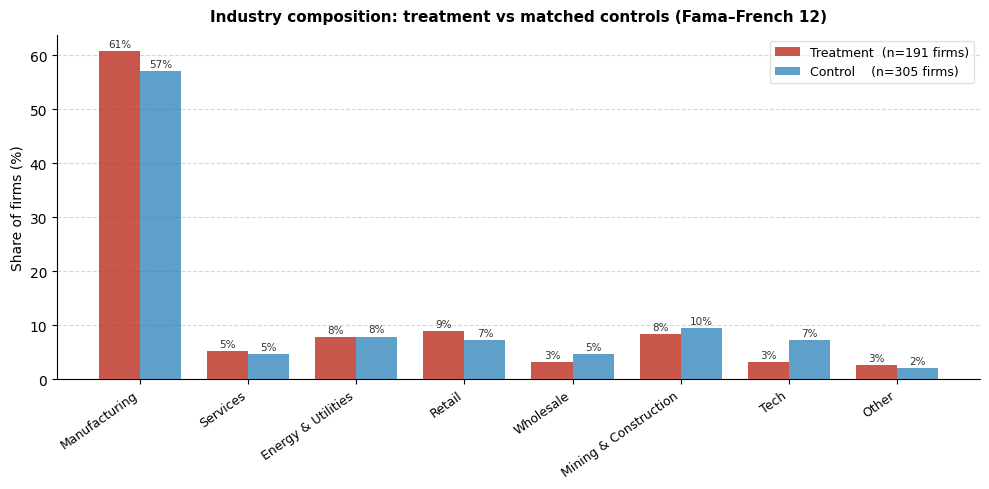

Saved → WR_sic_breakdown.png


In [14]:
# CELL 4.5 — Industry composition

FF12_BINS = [
    (range(100,  1000), "Agriculture"),
    (list(range(1000, 1500)) + list(range(1700, 2000)), "Mining & Construction"),
    (range(2000, 4000), "Manufacturing"),
    (range(4000, 5000), "Energy & Utilities"),
    (range(5000, 5200), "Wholesale"),
    (range(5200, 6000), "Retail"),
    (range(6000, 6500), "Finance"),
    (range(6500, 7000), "Real Estate"),
    (range(7000, 8000), "Services"),
    (range(8000, 8800), "Health & Education"),
    (range(7370, 7380), "Tech"),
]
FF12_ORDER = [
    "Manufacturing", "Finance", "Services", "Energy & Utilities",
    "Retail", "Wholesale", "Health & Education", "Mining & Construction",
    "Tech", "Real Estate", "Agriculture", "Other",
]

def sic_to_ff12(sic):
    try:
        s = int(sic)
    except (ValueError, TypeError):
        return "Other"
    if 7370 <= s < 7380:
        return "Tech"
    for rng, label in FF12_BINS:
        if s in rng:
            return label
    return "Other"

matches_df           = pd.read_csv(DATA_DIR / 'WR_control_matches.csv')
matched_treat_gvkeys = set(matches_df['treatment_gvkey'].unique())

treat = (
    master[master['sic'].notna() & master['gvkey'].isin(matched_treat_gvkeys)]
    .drop_duplicates('gvkey')[['gvkey', 'sic']]
    .copy()
)
treat['industry'] = treat['sic'].apply(sic_to_ff12)
treat_counts      = treat['industry'].value_counts()

ctrl = (
    matches_df[matches_df['control_sic'].notna()]
    .drop_duplicates('control_gvkey')[['control_gvkey', 'control_sic']]
    .copy()
)
ctrl['industry'] = ctrl['control_sic'].apply(sic_to_ff12)
ctrl_counts      = ctrl['industry'].value_counts()

all_industries = [i for i in FF12_ORDER
                  if i in treat_counts.index or i in ctrl_counts.index]

t_vals = np.array([treat_counts.get(i, 0) for i in all_industries])
c_vals = np.array([ctrl_counts.get(i,  0) for i in all_industries])
t_pct  = t_vals / t_vals.sum() * 100
c_pct  = c_vals / c_vals.sum() * 100

n     = len(all_industries)
x     = np.arange(n)
width = 0.38

fig, ax = plt.subplots(figsize=(10, 5))

bars_t = ax.bar(x - width / 2, t_pct, width, color='#C0392B', alpha=0.85,
                label=f'Treatment  (n={int(t_vals.sum())} firms)', zorder=3)
bars_c = ax.bar(x + width / 2, c_pct, width, color='#2980B9', alpha=0.75,
                label=f'Control    (n={int(c_vals.sum())} firms)', zorder=3)

for bar in list(bars_t) + list(bars_c):
    h = bar.get_height()
    if h >= 1.0:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.4,
                f'{h:.0f}%', ha='center', va='bottom', fontsize=7.5, color='#333')

ax.set_xticks(x)
ax.set_xticklabels(all_industries, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Share of firms (%)', fontsize=10)
ax.set_title('Industry composition: treatment vs matched controls (Fama–French 12)',
             fontsize=11, fontweight='bold', pad=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(framealpha=0.6, fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'WR_sic_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → WR_sic_breakdown.png")

## Section 5 – Credit & Debt Structure

S&P ratings and CIQ debt structure variables are added to the combined panel from Section 4, producing the final enriched dataset. Ratings are sourced from `comp_ratings` (primary) and supplemented by `comp.adsprate` where coverage is absent; both are merged as-of to the panel date to avoid look-ahead. CIQ debt structure is pulled from `ciq_capstrct.wrds_summary` and `ciq_capstrct.wrds_debt`, with CP outstanding capped at the reported facility size where double-counting is detected.

- **5.1** S&P ratings & CIQ balances
- **5.2** Debt structure enrichment & export

### 5.1 — S&P ratings & CIQ balances

Two rating sources are combined: `comp_ratings.erating` (primary) and `comp.adsprate` (supplement). Both are joined as-of to the panel date; `comp_ratings` takes precedence where both exist.

In [15]:
# CELL 5.1 — S&P ratings & CIQ balances

df = pd.read_csv(DATA_DIR / 'WR_wc_panel_with_controls.csv')

def clean_rating(x):
    return np.nan if x is None or x == 'None' or x == 'NR' else x

gvkey_map = db.raw_sql("""
    SELECT DISTINCT
        LPAD(CAST(gvkey AS VARCHAR), 6, '0') AS gvkey,
        entity_id
    FROM comp_ratings.erating_names
    WHERE gvkey IS NOT NULL
""")

entity_id_list = ", ".join("'" + str(e) + "'" for e in gvkey_map['entity_id'].unique())

ratings_raw = db.raw_sql("""
    SELECT
        entity_id,
        date     AS rating_date,
        srating  AS cr_short,
        lrating  AS cr_long,
        scwatch  AS cr_short_watch,
        lcwatch  AS cr_long_watch,
        loutlook AS cr_long_outlook
    FROM comp_ratings.erating
    WHERE "group" = 'ICR'
      AND type    = 'LOCAL CURRENCY'
      AND entity_id IN (""" + entity_id_list + """)
    ORDER BY entity_id, date
""")
ratings_raw['rating_date'] = pd.to_datetime(ratings_raw['rating_date'])

df['gvkey_str']   = df['gvkey'].astype(str).str.zfill(6)
df['datadate_dt'] = pd.to_datetime(df['datadate'])

keys = pd.DataFrame({
    'gvkey_str':   df['gvkey_str'],
    'datadate_dt': df['datadate_dt'],
})
keys = keys.merge(gvkey_map, left_on='gvkey_str', right_on='gvkey', how='left').drop(columns='gvkey')
keys = keys.merge(ratings_raw, on='entity_id', how='left')
keys = keys[keys['rating_date'] <= keys['datadate_dt']]
keys = (
    keys.sort_values('rating_date')
    .groupby(['gvkey_str', 'datadate_dt'], as_index=False)
    .last()
)

df = df.merge(
    keys[['gvkey_str', 'datadate_dt', 'cr_short', 'cr_long',
          'cr_short_watch', 'cr_long_watch', 'cr_long_outlook']],
    on=['gvkey_str', 'datadate_dt'], how='left'
)
for col in ['cr_short', 'cr_long', 'cr_short_watch', 'cr_long_watch', 'cr_long_outlook']:
    df[col] = df[col].apply(clean_rating)

our_gvkeys   = df['gvkey_str'].unique().tolist()
gvkey_chunks = [our_gvkeys[i:i+500] for i in range(0, len(our_gvkeys), 500)]

adsprate_list = []
for chunk in gvkey_chunks:
    chunk_str = ", ".join("'" + g + "'" for g in chunk)
    adsprate_list.append(db.raw_sql("""
        SELECT gvkey, datadate, spsticrm, splticrm
        FROM comp.adsprate
        WHERE gvkey IN (""" + chunk_str + """)
          AND datadate >= '1999-01-01'
    """))

adsprate = pd.concat(adsprate_list, ignore_index=True)
adsprate['datadate'] = pd.to_datetime(adsprate['datadate'])
for col in ['spsticrm', 'splticrm']:
    adsprate[col] = adsprate[col].apply(clean_rating)

df = df.merge(
    adsprate.rename(columns={
        'gvkey':    'gvkey_str',
        'datadate': 'datadate_dt',
        'spsticrm': 'adsp_short',
        'splticrm': 'adsp_long',
    }),
    on=['gvkey_str', 'datadate_dt'], how='left'
)

df['sp_short_term'] = df['cr_short'].combine_first(df['adsp_short'])
df['sp_long_term']  = df['cr_long'].combine_first(df['adsp_long'])
df['short_watch']   = df['cr_short_watch']
df['long_watch']    = df['cr_long_watch']
df['long_outlook']  = df['cr_long_outlook']

df = df.drop(columns=['cr_short', 'cr_long', 'cr_short_watch', 'cr_long_watch',
                       'cr_long_outlook', 'adsp_short', 'adsp_long'])

sp_short_order = {
    'A-1+': 1, 'A-1': 2, 'A-2': 3, 'A-3': 4,
    'B': 5, 'B-1': 5, 'B-2': 6, 'B-3': 7,
    'C': 8, 'D': 9, 'SD': 9, 'R': 10,
}
df['sp_short_term_num'] = df['sp_short_term'].map(sp_short_order)
df['sp_short_ig']       = df['sp_short_term_num'].apply(
    lambda x: 1 if pd.notna(x) and x <= 4 else (np.nan if pd.isna(x) else 0)
)

gvkey_sql = ", ".join(f"'{g}'" for g in our_gvkeys)
panel_min  = df['datadate_dt'].min()
panel_max  = df['datadate_dt'].max()

ciq_raw = db.raw_sql(f"""
    WITH ranked AS (
        SELECT
            gvkey,
            periodenddate,
            totoutstbalcommercialpaper,
            outstandingbalrrevolvingcredit,
            undrawncrdtportionrevolvingcrdt,
            totundrawncredit,
            principalamtdbtoutstanding,
            ROW_NUMBER() OVER (
                PARTITION BY gvkey, periodenddate
                ORDER BY filingdate DESC, financialinstanceid DESC
            ) AS rn
        FROM ciq_capstrct.wrds_summary
        WHERE gvkey IN ({gvkey_sql})
          AND latestforfinancialperiodflag = 1
          AND latestfilingforinstanceflag  = 1
          AND periodtypename               = 'Quarterly'
          AND periodenddate BETWEEN '{panel_min}' AND '{panel_max}'
    )
    SELECT * FROM ranked WHERE rn = 1
""")
ciq_raw['periodenddate'] = pd.to_datetime(ciq_raw['periodenddate'])
ciq_raw = ciq_raw.drop(columns='rn')

df         = df.sort_values(['gvkey_str', 'datadate_dt'])
ciq_sorted = (ciq_raw
    .rename(columns={'gvkey': 'gvkey_str', 'periodenddate': 'ciq_date'})
    .sort_values(['gvkey_str', 'ciq_date'])
)

ciq_cols = ['totoutstbalcommercialpaper', 'outstandingbalrrevolvingcredit',
            'undrawncrdtportionrevolvingcrdt', 'totundrawncredit',
            'principalamtdbtoutstanding']

merged_pieces = []
for gvkey, grp in df.groupby('gvkey_str'):
    ciq_grp = ciq_sorted[ciq_sorted['gvkey_str'] == gvkey][['ciq_date'] + ciq_cols]
    if ciq_grp.empty:
        for col in ciq_cols:
            grp[col] = np.nan
    else:
        grp = pd.merge_asof(
            grp, ciq_grp,
            left_on='datadate_dt', right_on='ciq_date',
            direction='backward', tolerance=pd.Timedelta('100 days')
        )
    merged_pieces.append(grp)

df = pd.concat(merged_pieces, ignore_index=True)

# Null out CIQ values where the matched periodenddate falls in a different calendar
# year than the panel row — prevents Dec-t balances bleeding into t+1 rows
year_mismatch = df['ciq_date'].notna() & (
    df['ciq_date'].dt.year != df['datadate_dt'].dt.year
)
df.loc[year_mismatch, ciq_cols] = np.nan
print(f"Year-boundary guard: nulled {year_mismatch.sum()} rows "
      f"({100*year_mismatch.sum()/len(df):.1f}%) where CIQ period year ≠ panel year")
df = df.drop(columns='ciq_date', errors='ignore')

df = df.rename(columns={
    'totoutstbalcommercialpaper':      'ciq_cp_outstanding',
    'outstandingbalrrevolvingcredit':  'ciq_revolver_drawn',
    'undrawncrdtportionrevolvingcrdt': 'ciq_revolver_undrawn',
    'totundrawncredit':                'ciq_total_undrawn',
    'principalamtdbtoutstanding':      'ciq_total_debt',
})

df['ciq_revolver_total'] = df['ciq_revolver_drawn'].add(df['ciq_revolver_undrawn'], fill_value=np.nan)
df['ciq_revolver_util']  = np.where(
    df['ciq_revolver_total'] > 0,
    df['ciq_revolver_drawn'] / df['ciq_revolver_total'], np.nan)
df['ciq_cp_pct_debt']       = np.where(df['ciq_total_debt'] > 0,
    df['ciq_cp_outstanding'] / df['ciq_total_debt'], np.nan)
df['ciq_revolver_pct_debt'] = np.where(df['ciq_total_debt'] > 0,
    df['ciq_revolver_drawn']  / df['ciq_total_debt'], np.nan)
df['ciq_has_cp']       = df['ciq_cp_outstanding'].notna().astype(int)
df['ciq_has_revolver'] = df['ciq_revolver_drawn'].notna().astype(int)

df = df.drop(columns=['gvkey_str', 'datadate_dt'])

total = len(df)
print("=" * 45)
print("RATINGS COVERAGE")
print("=" * 45)
has_short = df['sp_short_term'].notna().sum()
has_long  = df['sp_long_term'].notna().sum()
print(f"Total firm-quarters : {total}")
print(f"Short-term rated    : {has_short} ({round(100*has_short/total,1)}%)")
print(f"Long-term rated     : {has_long}  ({round(100*has_long/total,1)}%)")

print("\n" + "=" * 45)
print("CIQ CP / REVOLVER COVERAGE")
print("=" * 45)
for col in ['ciq_cp_outstanding', 'ciq_revolver_drawn', 'ciq_revolver_undrawn',
            'ciq_total_undrawn', 'ciq_total_debt', 'ciq_revolver_util',
            'ciq_cp_pct_debt', 'ciq_revolver_pct_debt']:
    n = df[col].notna().sum()
    print(f"  {col:35s}: {n:6d} / {total} ({100*n/total:.1f}%)")

print("\nBy group:")
print(df.groupby('group').agg(
    total        = ('gvkey', 'count'),
    has_short    = ('sp_short_term',      lambda x: x.notna().sum()),
    has_long     = ('sp_long_term',       lambda x: x.notna().sum()),
    has_cp       = ('ciq_cp_outstanding', lambda x: x.notna().sum()),
    has_revolver = ('ciq_revolver_drawn', lambda x: x.notna().sum()),
).assign(
    pct_short    = lambda x: (100 * x.has_short    / x.total).round(1),
    pct_long     = lambda x: (100 * x.has_long     / x.total).round(1),
    pct_cp       = lambda x: (100 * x.has_cp       / x.total).round(1),
    pct_revolver = lambda x: (100 * x.has_revolver / x.total).round(1),
).to_string())

Year-boundary guard: nulled 803 rows (1.7%) where CIQ period year ≠ panel year
RATINGS COVERAGE
Total firm-quarters : 46974
Short-term rated    : 17597 (37.5%)
Long-term rated     : 37201  (79.2%)

CIQ CP / REVOLVER COVERAGE
  ciq_cp_outstanding                 :  11793 / 46974 (25.1%)
  ciq_revolver_drawn                 :  28738 / 46974 (61.2%)
  ciq_revolver_undrawn               :  24265 / 46974 (51.7%)
  ciq_total_undrawn                  :  24752 / 46974 (52.7%)
  ciq_total_debt                     :  35722 / 46974 (76.0%)
  ciq_revolver_util                  :  22710 / 46974 (48.3%)
  ciq_cp_pct_debt                    :  11792 / 46974 (25.1%)
  ciq_revolver_pct_debt              :  28614 / 46974 (60.9%)

By group:
           total  has_short  has_long  has_cp  has_revolver  pct_short  pct_long  pct_cp  pct_revolver
group                                                                                                 
control    24139       2497     16960    1048         14332   

### 5.2 — Debt structure enrichment & export

CP outstanding from `wrds_debt` is capped at the reported facility size where both dataitem families are present and outstanding exceeds program, preventing double-counting. The USD filter is applied via `ciqcurrency`; fallback assumes `currencyid = 160`.

In [16]:
# CELL 5.2 — Debt structure enrichment & export

our_gvkeys = df['gvkey'].astype(str).str.zfill(6).unique().tolist()
gvkey_sql  = ', '.join(f"'{g}'" for g in our_gvkeys)
panel_min  = pd.to_datetime(df['datadate']).min()
panel_max  = pd.to_datetime(df['datadate']).max()

summ_ext = db.raw_sql(f"""
    WITH ranked AS (
        SELECT
            gvkey,
            periodenddate,
            outstandingbalrrevolvingcredit    AS revolver_drawn,
            undrawncrdtportionrevolvingcrdt   AS revolver_undrawn,
            undrawncreditportionofcp          AS cp_undrawn,
            outstandingbaltermloans           AS term_loans,
            totbankdbt                        AS bank_debt,
            convertibledbttot                 AS convertible_debt,
            fixedratedbt                      AS fixed_rate_debt,
            variableratedbt                   AS variable_rate_debt,
            srdbtebitda                       AS sr_debt_ebitda,
            secureddbt                        AS secured_debt,
            unsecureddbt                      AS unsecured_debt,
            ROW_NUMBER() OVER (
                PARTITION BY gvkey, periodenddate
                ORDER BY filingdate DESC, financialinstanceid DESC
            ) AS rn
        FROM ciq_capstrct.wrds_summary
        WHERE gvkey IN ({gvkey_sql})
          AND latestforfinancialperiodflag = 1
          AND latestfilingforinstanceflag  = 1
          AND periodtypename IN ('Annual', 'Quarterly')
          AND periodenddate BETWEEN '{panel_min}' AND '{panel_max}'
    )
    SELECT * FROM ranked WHERE rn = 1
""")
summ_ext['periodenddate'] = pd.to_datetime(summ_ext['periodenddate'])

summ_ext['revolver_capacity'] = (
    summ_ext['revolver_drawn'].fillna(0) + summ_ext['revolver_undrawn'].fillna(0)
)
summ_ext.loc[
    summ_ext['revolver_drawn'].isna() & summ_ext['revolver_undrawn'].isna(),
    'revolver_capacity'
] = np.nan
summ_ext = summ_ext.drop(columns=['revolver_drawn', 'revolver_undrawn', 'rn'])

usd_ids = {160}
try:
    cur     = db.raw_sql("SELECT * FROM ciq.ciqcurrency")
    iso_col = next(c for c in cur.columns if 'iso' in c.lower())
    usd_ids = set(cur.loc[cur[iso_col].astype(str).str.upper().eq('USD'), 'currencyid'])
    print(f"USD currencyid(s) resolved: {usd_ids}")
except Exception as e:
    print(f"ciqcurrency lookup failed ({type(e).__name__}); assuming USD id = 160")

usd_sql  = ', '.join(str(i) for i in usd_ids)
raw_debt = db.raw_sql(f"""
    SELECT gvkey, periodenddate, descriptiontext,
           dataitemvalue * CASE unittypeid
               WHEN 0 THEN 1.0
               WHEN 1 THEN 1000.0
               WHEN 2 THEN 1000000.0
               ELSE 1.0
           END / 1000000.0 AS value_m,
           issuedcurrencyid
    FROM ciq_capstrct.wrds_debt
    WHERE gvkey IN ({gvkey_sql})
      AND latestforfinancialperiodflag = 1
      AND descriptiontext IN ('Commercial paper', 'Commercial paper facility')
      AND dataitemvalue IS NOT NULL
      AND issuedcurrencyid IN ({usd_sql})
""")
raw_debt['periodenddate'] = pd.to_datetime(raw_debt['periodenddate'])
raw_debt = raw_debt.drop_duplicates(['gvkey', 'periodenddate', 'descriptiontext'])

cp_wide = (raw_debt.pivot_table(
               index=['gvkey', 'periodenddate'],
               columns='descriptiontext',
               values='value_m',
               aggfunc='sum')
           .reset_index()
           .rename(columns={
               'Commercial paper':          'cp_outstanding_debt',
               'Commercial paper facility': 'cp_program',
           }))

# Cap cp_outstanding at cp_program where both exist and outstanding > program
double_count = (cp_wide['cp_program'].notna()
                & cp_wide['cp_outstanding_debt'].notna()
                & (cp_wide['cp_outstanding_debt'] > cp_wide['cp_program']))
if double_count.sum():
    print(f"⚠ CP double-count cap applied to {double_count.sum()} firm-periods")
    cp_wide.loc[double_count, 'cp_outstanding_debt'] = cp_wide.loc[double_count, 'cp_program']

cp_prog    = cp_wide[['gvkey', 'periodenddate', 'cp_program']].dropna(subset=['cp_program'])
credit_ext = summ_ext.merge(cp_prog, on=['gvkey', 'periodenddate'], how='outer')
credit_ext = credit_ext.sort_values('periodenddate').reset_index(drop=True)

df['gvkey_str']   = df['gvkey'].astype(str).str.zfill(6)
df['datadate_dt'] = pd.to_datetime(df['datadate'])

df_sorted   = df.sort_values('datadate_dt').reset_index(drop=True)
cext_sorted = (credit_ext
               .rename(columns={'gvkey': 'gvkey_str', 'periodenddate': 'ext_date'})
               .sort_values('ext_date').reset_index(drop=True))

# 185-day tolerance reflects typical filing lag between period-end and WRDS availability
df_sorted = pd.merge_asof(
    df_sorted, cext_sorted,
    by='gvkey_str',
    left_on='datadate_dt',
    right_on='ext_date',
    direction='backward',
    tolerance=pd.Timedelta('185D')
).drop(columns='ext_date', errors='ignore')

ta = df_sorted['total_assets'].replace(0, np.nan)

df_sorted['revolver_utilization'] = np.where(
    df_sorted['revolver_capacity'] > 0,
    df_sorted['ciq_revolver_drawn'] / df_sorted['revolver_capacity'], np.nan)
df_sorted['cp_utilization']       = np.where(
    df_sorted['cp_program'] > 0,
    df_sorted['ciq_cp_outstanding'] / df_sorted['cp_program'], np.nan)
df_sorted['revcap_to_assets']     = df_sorted['revolver_capacity'] / ta
df_sorted['cp_undrawn_to_assets'] = df_sorted['cp_undrawn']        / ta
df_sorted['term_loans_to_assets'] = df_sorted['term_loans']        / ta
df_sorted['bank_debt_to_assets']  = df_sorted['bank_debt']         / ta

for col in ['revolver_utilization', 'cp_utilization']:
    s = df_sorted[col].replace([np.inf, -np.inf], np.nan)
    m = s.notna()
    if m.sum() > 1:
        s[m] = mstats.winsorize(s[m].to_numpy(float), limits=[0.01, 0.01])
    df_sorted[col] = s

cp_out_usd    = (cp_wide[['gvkey', 'periodenddate', 'cp_outstanding_debt']]
                 .dropna(subset=['cp_outstanding_debt'])
                 .rename(columns={'gvkey': 'gvkey_str', 'periodenddate': 'cp_date'}))
cp_out_sorted = cp_out_usd.sort_values('cp_date').reset_index(drop=True)

df_sorted = pd.merge_asof(
    df_sorted, cp_out_sorted,
    by='gvkey_str',
    left_on='datadate_dt',
    right_on='cp_date',
    direction='backward',
    tolerance=pd.Timedelta('185D')
)

# Same year-boundary guard as 5.1 — prevents prior-year CP balances bleeding forward
year_mismatch_debt = df_sorted['cp_date'].notna() & (
    df_sorted['cp_date'].dt.year != df_sorted['datadate_dt'].dt.year
)
df_sorted.loc[year_mismatch_debt, 'cp_outstanding_debt'] = np.nan
print(f"Year-boundary guard: nulled {year_mismatch_debt.sum()} cp_outstanding_debt rows "
      f"({100*year_mismatch_debt.sum()/len(df_sorted):.1f}%)")
df_sorted = df_sorted.drop(columns='cp_date', errors='ignore')

df_sorted['ciq_cp_outstanding'] = (
    df_sorted['cp_outstanding_debt']
    .combine_first(df_sorted['ciq_cp_outstanding'])
)
df_sorted = df_sorted.drop(columns='cp_outstanding_debt', errors='ignore')

df_sorted = df_sorted.drop(columns=['has_revolver', 'has_cp', 'has_credit_data',
                                     'ciq_has_cp', 'ciq_has_revolver',
                                     'ciq_revolver_total', 'ciq_revolver_util'], errors='ignore')

df_sorted['has_revolver']    = df_sorted['revolver_capacity'].notna().astype(int)
df_sorted['has_cp']          = df_sorted['ciq_cp_outstanding'].notna().astype(int)
df_sorted['has_credit_data'] = (
    df_sorted['revolver_capacity'].notna() | df_sorted['ciq_cp_outstanding'].notna()
).astype(int)

df_sorted = df_sorted.drop(columns=['gvkey_str', 'datadate_dt'])

total = len(df_sorted)
print("=" * 55)
print("EXTENDED COVERAGE REPORT")
print("=" * 55)
print(f"{'Metric':<35} {'N':>7}  {'%':>6}")
print("-" * 55)

report_cols = [
    ('revolver_capacity',    'revolver_capacity'),
    ('revolver_utilization', 'revolver_utilization'),
    ('cp_program',           'cp_program'),
    ('cp_utilization',       'cp_utilization'),
    ('cp_undrawn',           'cp_undrawn'),
    ('ciq_cp_outstanding',   'ciq_cp_outstanding'),
    ('term_loans',           'term_loans'),
    ('bank_debt',            'bank_debt'),
    ('convertible_debt',     'convertible_debt'),
    ('fixed_rate_debt',      'fixed_rate_debt'),
    ('variable_rate_debt',   'variable_rate_debt'),
    ('sr_debt_ebitda',       'sr_debt_ebitda'),
    ('secured_debt',         'secured_debt'),
    ('unsecured_debt',       'unsecured_debt'),
]

for label, col in report_cols:
    if col not in df_sorted.columns:
        continue
    n = df_sorted[col].notna().sum()
    print(f"  {label:<33} {n:>7,}  {100*n/total:>5.1f}%")

print(f"  {'has_revolver flag':<33} {df_sorted['has_revolver'].sum():>7,}  {100*df_sorted['has_revolver'].mean():>5.1f}%")
print(f"  {'has_cp flag':<33} {df_sorted['has_cp'].sum():>7,}  {100*df_sorted['has_cp'].mean():>5.1f}%")
print(f"  {'has_credit_data flag':<33} {df_sorted['has_credit_data'].sum():>7,}  {100*df_sorted['has_credit_data'].mean():>5.1f}%")

print(f"\nBy group:")
print(df_sorted.groupby('group').agg(
    rows           = ('gvkey',              'count'),
    has_revcap     = ('revolver_capacity',    lambda x: x.notna().sum()),
    has_rev_util   = ('revolver_utilization', lambda x: x.notna().sum()),
    has_cp_out     = ('ciq_cp_outstanding',   lambda x: x.notna().sum()),
    has_cp_prog    = ('cp_program',           lambda x: x.notna().sum()),
    has_term_loans = ('term_loans',           lambda x: x.notna().sum()),
    has_bank_debt  = ('bank_debt',            lambda x: x.notna().sum()),
).assign(
    pct_revcap     = lambda x: (100 * x.has_revcap     / x.rows).round(1),
    pct_rev_util   = lambda x: (100 * x.has_rev_util   / x.rows).round(1),
    pct_cp_out     = lambda x: (100 * x.has_cp_out     / x.rows).round(1),
    pct_cp_prog    = lambda x: (100 * x.has_cp_prog    / x.rows).round(1),
    pct_term_loans = lambda x: (100 * x.has_term_loans / x.rows).round(1),
    pct_bank_debt  = lambda x: (100 * x.has_bank_debt  / x.rows).round(1),
).to_string())

print(f"\ndf shape: {df_sorted.shape}")

df_sorted.to_csv(DATA_DIR / 'WR_wc_panel_enriched.csv', index=False)
print(f"\nSaved → WR_wc_panel_enriched.csv  "
      f"({len(df_sorted):,} rows, {df_sorted['gvkey'].nunique()} firms, "
      f"{df_sorted.shape[1]} columns)")

USD currencyid(s) resolved: {160}
⚠ CP double-count cap applied to 22 firm-periods
Year-boundary guard: nulled 1635 cp_outstanding_debt rows (3.5%)
EXTENDED COVERAGE REPORT
Metric                                    N       %
-------------------------------------------------------
  revolver_capacity                  30,964   65.9%
  revolver_utilization               26,288   56.0%
  cp_program                          1,140    2.4%
  cp_utilization                      1,129    2.4%
  cp_undrawn                          1,328    2.8%
  ciq_cp_outstanding                 12,892   27.4%
  term_loans                         16,030   34.1%
  bank_debt                          31,746   67.6%
  convertible_debt                    5,560   11.8%
  fixed_rate_debt                    33,008   70.3%
  variable_rate_debt                 28,188   60.0%
  sr_debt_ebitda                     36,545   77.8%
  secured_debt                       25,889   55.1%
  unsecured_debt                     35,469